In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Clone Repository**

In [ ]:
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 967 (delta 98), reused 93 (delta 93), pack-reused 848 (from 1)
Receiving objects: 100% (967/967), 62.52 MiB | 26.01 MiB/s, done.
Resolving deltas: 100% (476/476), done.
/content/MedSAM


**Install Dependencies**

In [ ]:
!pip install -e .

Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.2 MB/s eta 0:00:00
  Running setup.py develop for medsam


**Imports**

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from skimage import io, transform
from segment_anything import sam_model_registry

**Device**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


**Load MedSAM Model**

In [ ]:
checkpoint = "/content/drive/MyDrive/MedSAM/medsam_vit_b.pth"

medsam_model = sam_model_registry["vit_b"](checkpoint=checkpoint)


medsam_model = medsam_model.to(device)
medsam_model.eval()

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


**Load Image**

In [ ]:
image_path = "assets/img_demo.png"

img_np = io.imread(image_path)

if len(img_np.shape) == 2:
    img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
else:
    img_3c = img_np

H, W, _ = img_3c.shape

**Image Preprocessing**

In [ ]:
img_1024 = transform.resize(
    img_3c,
    (1024,1024),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.uint8)

img_1024 = (
    img_1024 - img_1024.min()
) / np.clip(
    img_1024.max()-img_1024.min(),
    a_min=1e-8,
    a_max=None
)

img_tensor = (
    torch.tensor(img_1024)
    .float()
    .permute(2,0,1)
    .unsqueeze(0)
    .to(device)
)

**Image Embedding**

In [ ]:
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_tensor)

**Original Bounding Box**

In [ ]:
box = [95,255,190,350]

box_1024 = (
    np.array(box)
    / np.array([W,H,W,H])
    *1024
)

**Generate Multiple Boxes**

In [ ]:
def generate_multiple_boxes(box, n_boxes=5, jitter=10):
    """
    Generate multiple perturbed bounding boxes.

    Parameters:
        box : list or numpy array [x1, y1, x2, y2]
        n_boxes : number of boxes
        jitter : maximum perturbation in pixels

    Returns:
        List of perturbed bounding boxes
    """

    x1, y1, x2, y2 = box
    boxes = []

    # Keep original box
    boxes.append([x1, y1, x2, y2])

    # Generate remaining perturbed boxes
    for _ in range(n_boxes - 1):

        new_x1 = max(0, x1 + random.randint(-jitter, jitter))
        new_y1 = max(0, y1 + random.randint(-jitter, jitter))
        new_x2 = max(0, x2 + random.randint(-jitter, jitter))
        new_y2 = max(0, y2 + random.randint(-jitter, jitter))

        new_x1, new_x2 = sorted([new_x1, new_x2])
        new_y1, new_y2 = sorted([new_y1, new_y2])

        boxes.append([new_x1, new_y1, new_x2, new_y2])

    return boxes

**Generate Boxes**

In [ ]:
boxes = generate_multiple_boxes(
    box_1024,
    n_boxes=5,
    jitter=40
)

print("Generated Boxes:")
for i, box in enumerate(boxes, start=1):
    print(f"Box {i}: {box}")

Generated Boxes:
Box 1: [np.float64(190.0), np.float64(510.0), np.float64(380.0), np.float64(700.0)]
Box 2: [np.float64(185.0), np.float64(545.0), np.float64(354.0), np.float64(693.0)]
Box 3: [np.float64(150.0), np.float64(501.0), np.float64(394.0), np.float64(707.0)]
Box 4: [np.float64(207.0), np.float64(504.0), np.float64(363.0), np.float64(670.0)]
Box 5: [np.float64(161.0), np.float64(513.0), np.float64(400.0), np.float64(736.0)]


**medsam_inference()**

In [ ]:
@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]  # (B, 1, 4)

    sparse_embeddings, dense_7yuembeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,  # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
        multimask_output=False,
    )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)

    low_res_pred = low_res_pred.squeeze().detach().cpu().numpy()
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)

    return medsam_seg, low_res_pred

**Generate Probability maps**

In [ ]:
all_masks = []
probability_maps = []

for box in boxes:

    mask, probability = medsam_inference(
        medsam_model,
        image_embedding,
        np.array([box]),
        H,
        W
    )

    all_masks.append(mask)
    probability_maps.append(probability)

In [ ]:
#Verify
print("Number of masks:", len(all_masks))
print("Number of probability maps:", len(probability_maps))

print("Mask shape:", all_masks[0].shape)
print("Probability map shape:", probability_maps[0].shape)

print("Probability range:")
print("Min:", probability_maps[0].min())
print("Max:", probability_maps[0].max())

Number of masks: 5
Number of probability maps: 5
Mask shape: (512, 512)
Probability map shape: (512, 512)
Probability range:
Min: 4.6600346e-10
Max: 0.99999857


**Visualization**

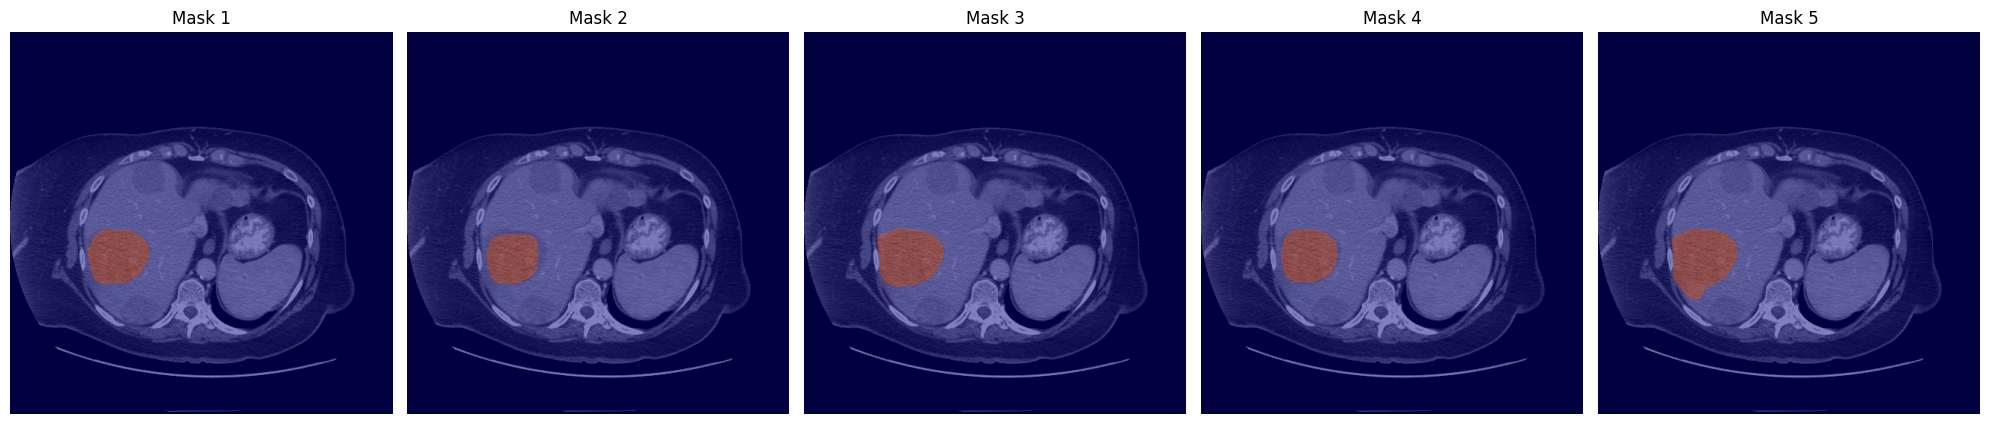

In [ ]:
#Masks
fig, axes = plt.subplots(1, len(all_masks), figsize=(20,5))

for i, mask in enumerate(all_masks):

    axes[i].imshow(img_3c)                     # Original image
    axes[i].imshow(mask, alpha=0.5, cmap="jet") # Overlay prediction
    axes[i].set_title(f"Mask {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

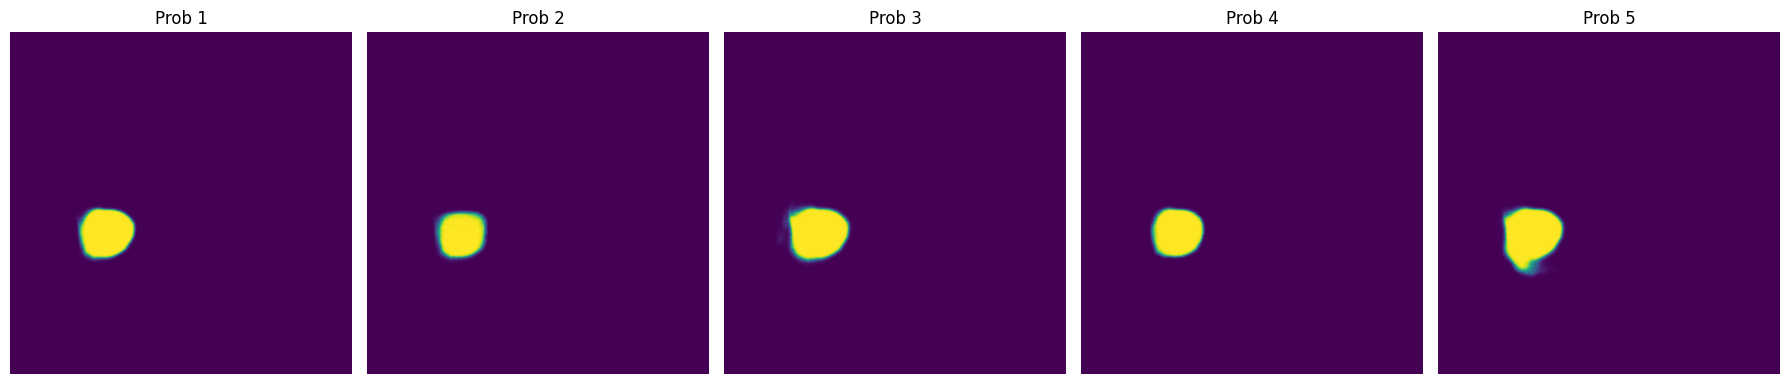

In [ ]:
#Probability Maps
fig, axes = plt.subplots(1, 5, figsize=(18,5))

for i, prob in enumerate(probability_maps):

    axes[i].imshow(prob, cmap="viridis")
    axes[i].set_title(f"Prob {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Uncertainty Estimation**

In [ ]:
#Stack Probability

probability_maps = np.stack(probability_maps)

print(probability_maps.shape)

#Mean Probability

mean_probability = np.mean(probability_maps, axis=0)

print(mean_probability.shape)

#Compute Entropy

epsilon = 1e-8

entropy = -(
    mean_probability * np.log(mean_probability + epsilon)
    +
    (1 - mean_probability)
    * np.log(1 - mean_probability + epsilon)
)

(5, 512, 512)
(512, 512)


**Visualize Entropy**

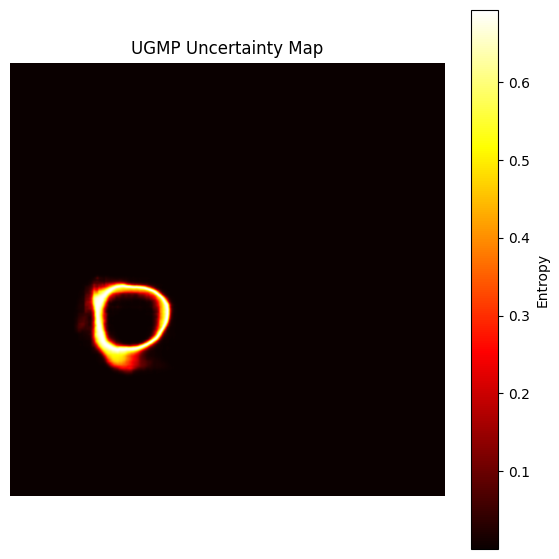

In [ ]:
plt.figure(figsize=(7,7))

plt.imshow(entropy, cmap="hot")

plt.colorbar(label="Entropy")

plt.title("UGMP Uncertainty Map")

plt.axis("off")

plt.show()

**Overlay Entropy on Original Image**

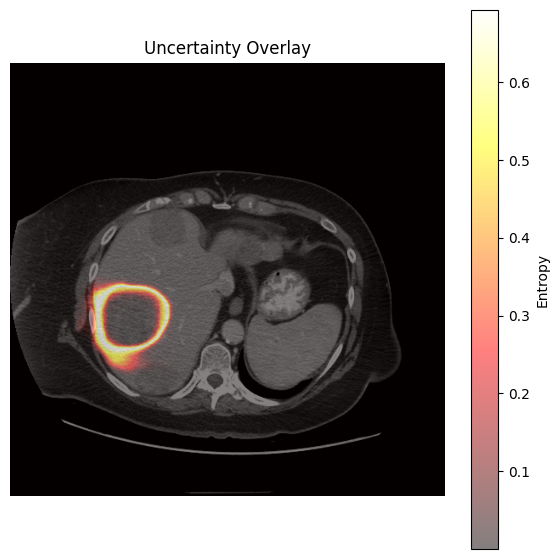

In [ ]:
plt.figure(figsize=(7,7))

plt.imshow(img_3c)

plt.imshow(entropy, cmap="hot", alpha=0.5)

plt.colorbar(label="Entropy")

plt.title("Uncertainty Overlay")

plt.axis("off")

plt.show()